# Data Analysis & Preprocessing Lab

This notebook covers three main tasks:
1. Premier League Top Scorers Analysis
2. Titanic Dataset Visualization
3. Telco Customer Churn Dataset Preparation

## Question 1: Premier League Top Scorers Analysis

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [15]:
df_score=pd.read_csv('/content/drive/MyDrive/LAB01/needed_files/Top_Scorers_dataset.csv')
df_player=pd.read_json('/content/drive/MyDrive/LAB01/needed_files/players_stats.json')

all_data=pd.merge(df_score,df_player,on='Name')

all_data.head(5)

,Rank,Name,Nationality,Goals,Height_cm,Appearances,Wins,Losses,Goals_per_match,Assists,Yellow_cards,Red_cards
0,1,Alan Shearer,England,260,183,441,203,129,0.59,64,41,2
1,2,Wayne Rooney,England,208,176,491,284,103,0.42,103,102,3
2,3,Andrew Cole,England,187,178,414,206,106,0.45,73,40,6
3,4,Sergio Agüero,Argentina,184,173,275,186,45,0.67,47,23,1
4,5,Frank Lampard,England,177,184,609,349,127,0.29,102,59,2


Visualization: Scatter Plot - Appearances vs Goals



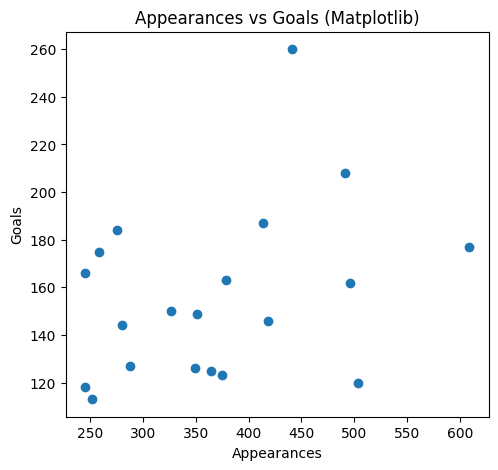

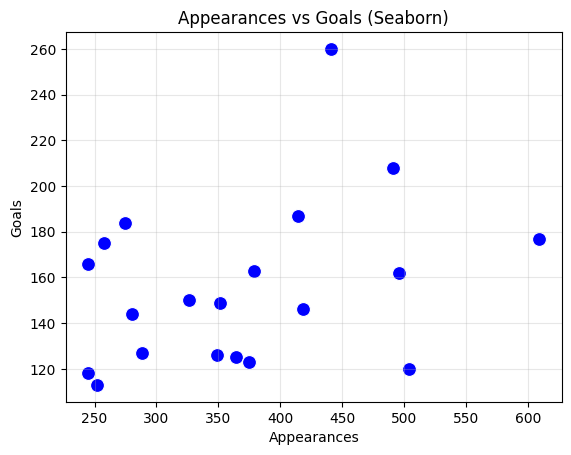

In [16]:
print("Visualization: Scatter Plot - Appearances vs Goals\n")
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(all_data['Appearances'],all_data['Goals'],colorizer='r')
plt.xlabel('Appearances')
plt.ylabel('Goals')
plt.title('Appearances vs Goals (Matplotlib)')
plt.show()

sns.scatterplot(x='Appearances', y='Goals', data=all_data, color='b', s=100)
plt.title('Appearances vs Goals (Seaborn)')
plt.grid(True, alpha=0.3)

plt.show()

## Question 2: Titanic Dataset Visualization

Load the Titanic dataset and create a histogram for Age distribution.

In [17]:
titanic_df=sns.load_dataset('titanic')
titanic_df.head(5)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


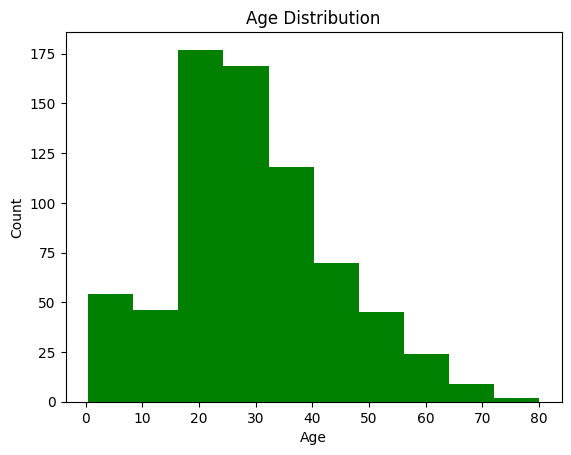

In [18]:
plt.hist(titanic_df['age'],bins=10,color='g')
plt.xlabel('Age')
plt.ylabel('Count')
plt.title('Age Distribution')
plt.show()

## Question 3: Telco Customer Churn Dataset Preparation

Comprehensive data preprocessing including data cleaning, encoding, and normalization.

In [19]:
df_we=pd.read_csv('/content/drive/MyDrive/LAB01/needed_files/WA_Fn-UseC_-Telco-Customer-Churn.csv')
df_copy=df_we.copy()
df_we.head(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,NaN,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [20]:
df_we.drop('customerID', axis=1, inplace=True)

print("Dataset after dropping customerID:")
print("Shape:", df_we.shape)
df_we.head(5)

Dataset after dropping customerID:
Shape: (7043, 20)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,NaN,56.95,1889.5,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [21]:
df_we['TotalCharges'] = pd.to_numeric(df_we['TotalCharges'], errors='coerce')

null_count = df_we['TotalCharges'].isnull().sum()
print(f"Number of missing values in TotalCharges: {null_count}")

Number of missing values in TotalCharges: 11


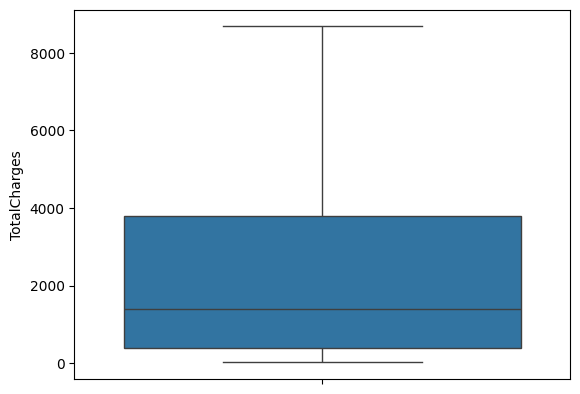

In [22]:
sns.boxplot(y=df_we['TotalCharges'])
plt.show()

In [23]:
def cat_to_num(df, col):
    dummies = pd.get_dummies(df[col], prefix=col, drop_first=False)
    df = pd.concat([df.drop(col, axis=1), dummies], axis=1)
    return df

for col in df_we.columns:
    if df_we[col].dtype == 'object' and col not in ['Contract', 'Churn']:
        df_we = cat_to_num(df_we, col)

In [24]:
df_we['Contract'].unique()

array(['Month-to-month', 'One year', 'Two year'], dtype=object)

In [25]:
df_we['Contract'].replace({'Month-to-month':1,'One year':2,'Two year':3},inplace=True)

/tmp/ipython-input-1647572271.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_we['Contract'].replace({'Month-to-month':1,'One year':2,'Two year':3},inplace=True)
/tmp/ipython-input-1647572271.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_we['Contract'].replace({'Month-to-month':1,'On

In [26]:
df_we['Contract']=pd.to_numeric(df_we['Contract'],errors='coerce')
print("The Number of Null Values in Contract = ",df_we['Contract'].isnull().sum())

The Number of Null Values in Contract =  0


In [27]:
#Check Duplicated Data
print(df_we.duplicated().sum())
#Remove Duplicated Data
df_we.drop_duplicates(inplace=True)

22


In [28]:
print(df_we.duplicated().sum())

0


In [29]:
df_we['Churn'].replace({'Yes':1,'No':0},inplace=True)
df_we['Churn']=pd.to_numeric(df_we['Churn'],errors='coerce')
print("The Number of Null Values in Churn = ",df_we['Churn'].isnull().sum())

The Number of Null Values in Churn =  0


/tmp/ipython-input-69273556.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_we['Churn'].replace({'Yes':1,'No':0},inplace=True)
/tmp/ipython-input-69273556.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_we['Churn'].replace({'Yes':1,'No':0},inplace=True)


In [30]:
target=df_we['Churn']
features=df_we.drop('Churn',axis=1)

In [31]:
customerID=df_copy['customerID']
target=pd.concat([customerID,target],axis=1)
target.head(5)

,customerID,Churn
0,7590-VHVEG,0.0
1,5575-GNVDE,0.0
2,3668-QPYBK,1.0
3,7795-CFOCW,0.0
4,9237-HQITU,1.0


In [32]:
# do normalization for all numerical columns
from sklearn.preprocessing import MinMaxScaler
num_cols=features.select_dtypes(include=['float64','int64']).columns
print(num_cols)
scaler=MinMaxScaler()
features[num_cols]=scaler.fit_transform(features[num_cols])
features.head(5)

Index(['SeniorCitizen', 'tenure', 'Contract', 'MonthlyCharges',
       'TotalCharges'],
      dtype='object')


,SeniorCitizen,tenure,Contract,MonthlyCharges,TotalCharges,gender_Female,gender_Male,Partner_No,Partner_Yes,Dependents_No,...,StreamingTV_Yes,StreamingMovies_No,StreamingMovies_No internet service,StreamingMovies_Yes,PaperlessBilling_No,PaperlessBilling_Yes,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0.0,0.013889,0.0,0.115423,0.001275,True,False,False,True,True,...,False,True,False,False,False,True,False,False,True,False
1,0.0,0.472222,0.5,0.385075,0.215867,False,True,True,False,True,...,False,True,False,False,True,False,False,False,False,False
2,0.0,0.027778,0.0,0.354229,0.010310,False,True,True,False,True,...,False,True,False,False,False,True,False,False,False,True
3,0.0,0.625000,0.5,0.239303,0.210241,False,True,True,False,True,...,False,True,False,False,True,False,True,False,False,False
4,0.0,0.027778,0.0,0.521891,0.015330,True,False,True,False,True,...,False,True,False,False,False,True,False,False,True,False


In [33]:
features.to_csv('/content/drive/MyDrive/LAB01/features.csv',index=False)
target.to_csv('/content/drive/MyDrive/LAB01/target.csv',index=False)

## Question 4

In [34]:
training_losses = [31.935606,
31.679361,
30.987786,
30.263454,
29.400899,
28.349332,
28.051839,
27.776177,
27.375563,
27.142823,
26.770814,
26.581287,
26.074585,
25.877744,
25.558349,
25.111712,
24.865791,
24.501421,
24.148419,
23.669787,
23.310746,
22.987978,
22.544164,
22.02776,
21.612261,
21.15004,
20.595727,
20.069397,
19.664952,
18.940667,
18.530784,
17.736587,
17.254536,
16.749037,
15.889799,
15.21916,
14.654819,
13.837178,
13.311737,
12.447598,
11.733485,
11.309702,
10.736487,
10.230713,
9.503306,
8.699232,
8.431897,
7.600132]

In [35]:
validation_losses = [5.579518,
5.566535,
5.439262,
5.363996,
5.368029,
5.307929,
5.203864,
5.157347,
5.17553,
5.277766,
5.15471,
5.132692,
5.115165,
5.017723,
5.106299,
4.975789,
4.900855,
5.081902,
4.894233,
4.797931,
4.728219,
4.817321,
4.93361,
4.649485,
4.843625,
4.767582,
4.786331,
4.604632,
4.587459,
4.61164,
4.669691,
4.561758,
4.714008,
4.618539,
4.602214,
4.544652,
5.097597,
4.194339,
4.237294,
4.611084,
4.200398,
4.343265,
4.523245,
4.479331,
4.606778,
4.429471,
4.480304,
4.211359]

Text(0, 0.5, 'Loss')

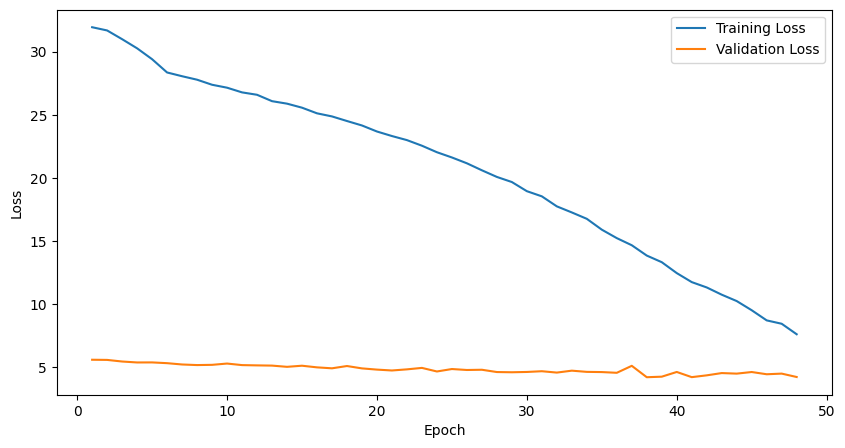

In [36]:
plt.figure(figsize=(10,5))
sns.lineplot(x=range(1,len(training_losses)+1),y=training_losses,label='Training Loss')
sns.lineplot(x=range(1,len(validation_losses)+1),y=validation_losses,label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')